# 📊 Provider Log EDA — CodeCritic Execution Trace Analysis

This notebook performs exploratory data analysis (EDA) on the **provider log** from a CodeCritic execution session. It reconstructs the execution flow, visualizes system behavior, and highlights key performance and decision-making patterns.

## 🔍 Contents

- **Execution Timeline**: Step-by-step trace of providers, inputs, and outputs
- **Call Frequency**: Counts how often each `provider_type` is invoked
- **Latency Analysis**:
  - Total latency by provider type
  - Normalized latency per call
- **FSM State Transitions**:
  - State visit frequency (system + state providers)
  - Step count distribution
- **File Evolution Diagrams**:
  - Graphs showing how files are transformed across providers
- **Agent Behavior**:
  - Decision traces with reason summaries
  - Tool and score correlation
- **Interactive Visuals**:
  - Treemaps, Sankey diagrams, bar charts, and scatter plots

## 🎯 Goal

The goal of this notebook is to **understand system performance and execution flow**, identify **costly or unstable phases**, and surface opportunities for optimization, caching, or design refinement within the CodeCritic engine.


### 🛠️ Project Root Setup + Database Reset and Seeding

This cell resets the entire database schema and seeds it with initial data. It is typically used in local development or test environments before running sessions.

#### 🧠 What this code does:

1. **Sets the working directory** to the project root (`C:\Repos\codecritic`) so all relative imports and paths resolve correctly.
2. **Imports all seeders** from `app.db.seeders` to populate the database with provider and configuration records.
3. **Drops and recreates** all tables using SQLAlchemy’s `Base.metadata.drop_all()` and `create_all()` for a clean start.
4. **Runs all seeders** in a single transaction using `Session(bind=engine)` to insert:
   - Prompts and prompt providers
   - Tools, scores, and agent engines
   - Agents, states, systems, controllers, programs, and sessions
5. **Loads environment variables** from `env/.env` relative to the project root.

#### 🔍 Why it matters:

- Ensures the system starts from a **clean and reproducible state**
- Guarantees that all required provider records are seeded before executing sessions
- Makes local development or testing **deterministic**
- Prepares the environment for any downstream scripts, agents, or workflows

Use this cell at the start of notebooks that need access to a freshly initialized and fully seeded CodeCritic environment.


In [1]:
from pathlib import Path
import os, sys
from dotenv import load_dotenv

# Set working directory explicitly to project root
PROJECT_ROOT = Path(r"C:\Repos\codecritic").resolve()

os.chdir(PROJECT_ROOT)  # Change current directory
sys.path.insert(0, str(PROJECT_ROOT))  # Ensure imports resolve correctly

print("Working directory is now:", Path.cwd())

from app.db.connection import DB_PATH, close_connection
from sqlalchemy import create_engine
from app.db.seeders.seed_score_providers import seed_score_providers
from app.db.seeders.seed_tool_providers import seed_tool_providers
from app.db.seeders.seed_prompt_providers import seed_prompt_providers
from app.db.seeders.seed_prompts import seed_prompts
from app.db.seeders.seed_context_providers import seed_context_providers
from app.db.seeders.seed_agent_engine_providers import seed_agent_engine_providers
from app.db.seeders.seed_agent_providers import seed_agent_providers
from app.db.seeders.seed_state_providers import seed_state_providers
from app.db.seeders.seed_system_providers import seed_system_providers
from app.db.seeders.seed_controller_providers import seed_controller_providers
from app.db.seeders.seed_program_provider import seed_program_providers
from app.db.seeders.seed_session_configs import seed_session_configs
from app.db.base import Base
from sqlalchemy.orm import Session

# 🧹 Reset DB
close_connection()
engine = create_engine(f"sqlite:///{DB_PATH}")
Base.metadata.drop_all(engine)
Base.metadata.create_all(engine)

# 🌱 Seed database records
with Session(bind=engine) as session:
    seed_prompts(session)
    seed_prompt_providers(session)
    seed_tool_providers(session)
    seed_score_providers(session)
    seed_context_providers(session)
    seed_agent_engine_providers(session)
    seed_agent_providers(session)
    seed_state_providers(session)
    seed_system_providers(session)
    seed_controller_providers(session)
    seed_program_providers(session)
    seed_session_configs(session)

# Load from env/.env relative to project root
dotenv_path = Path("env/.env").resolve()
if dotenv_path.exists():
    load_dotenv(dotenv_path)
    print("✅ Loaded environment variables from env/.env")
else:
    raise FileNotFoundError(f"❌ Missing .env file at: {dotenv_path}")


Working directory is now: C:\Repos\codecritic
Seeded AgentPrompt 'generate' with ID: 1 and GUID: 7230667f-b3e9-426b-8e44-14b49e33cb2d
Seeded AgentPrompt 'linting_generator_agent' with ID: 2 and GUID: 1a21e34d-aa8b-41f5-9fa5-97081f71160a
Seeded SystemPrompt 'format' with ID: 1 and GUID: c20f71a5-3fab-4834-a5b7-dc4d34700671
Seeded SystemPrompt 'linting_system' with ID: 2 and GUID: 629dac81-b90a-471b-a9c4-5fe787c67344
Seeded prompt provider configurations successfully.
Seeded tool configurations successfully.
Seeded score providers successfully.
Seeded context provider configurations successfully.
Seeded agent engine configurations successfully.
Seeded agent provider configurations successfully.
✅ Seeded state provider configurations successfully.
Seeded system provider configurations successfully.
✅ Seeded controller providers
✅ Seeded program providers
✅ Seeded session configs
✅ Loaded environment variables from env/.env


In [2]:
# 🧪 Run Program Using SessionConfig

from app.db.models import SessionConfig
from app.enums.logging_enums import PROVIDER_TYPE
from app.enums.system_enums import SYSTEM_TYPE
from app.factories.program_provider_factory import ProgramProviderFactory
from sqlalchemy.orm import Session
from pathlib import Path
import json

# Fetch session config
with Session(bind=engine) as db:
    session_row = db.query(SessionConfig).filter_by(id=1).first()
    assert session_row, "❌ No session config found"

# Prepare test file
file = Path("tests/session_linked_execution.py")
file.write_text("def ping( user ):\n return f\"pong {user}\"")

# Construct input using session metadata
input_data = {
    "file_path":  str(file),
    "session_id": session_row.id,
    "system":     SYSTEM_TYPE.LINTING.value
}

# Run associated program
program = ProgramProviderFactory.create(
    id=session_row.program_provider_id,
    called_by_type=PROVIDER_TYPE.SESSION,
    called_by_id=session_row.id
)
result = program.run(input_data, session_id=session_row.id)

print("✅ Final Program Result (via SessionConfig):")
print(json.dumps(result.model_dump(), indent=2))


✅ Final Program Result (via SessionConfig):
{
  "state": "end",
  "previous_state": "preprocessing",
  "state_type": "end",
  "decision": "accept",
  "steps": 2,
  "max_steps": 20,
  "summary": "preprocessing complete",
  "output": {
    "state": "end",
    "file_path": "working_files\\final_prog_1525257908.py",
    "session_id": 1,
    "system": "linting",
    "reason": "preprocessing complete",
    "steps": 2,
    "retry_count": 0,
    "_last_state": "preprocessing",
    "decision": "accept",
    "score": null,
    "state_output": {
      "state": "end",
      "previous_state": "preprocess",
      "state_type": "end",
      "decision": "accept",
      "steps": 2,
      "max_steps": 10,
      "summary": "Completed",
      "provider_name": "preprocessing_controller"
    }
  },
  "provider_name": "codecritic_program"
}


### Load raw log entries

### 🧾 Full Execution Trace (Provider Log Step-by-Step)

This code cell loads and prints a **chronological step-by-step trace** of provider executions for a specific session.

#### 🧠 What this code does:
- Connects to the SQLite database and loads `provider_log` rows for `session_id = 1`.
- Sorts the entries by timestamp to reconstruct the actual execution timeline.
- Iterates over each row and prints a formatted log containing:
  - Timestamp and provider metadata
  - File name and latency
  - Config and call chain info
  - Parsed input and output fields (truncated if long)

#### 🔍 What you're observing:
- Each **step** shows the complete context of a provider call:
  - Who it was **called by**
  - What it **received** (input)
  - What it **produced** (output)
- Provides an **audit-like view** that’s useful for debugging, compliance, or understanding system orchestration logic.
- Can reveal:
  - Repeated calls
  - Delays or outliers
  - Input/output mismatches
  - Provider chain inconsistencies

This is the foundation for building trace visualizations, debugging sessions, or generating compliance audit trails.


In [3]:
import sqlite3
import pandas as pd
import json
from app.db.connection import DB_PATH

# Connect and load logs
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql("SELECT * FROM provider_log WHERE session_id='1'", conn)
conn.close()

# Sort by timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by='timestamp').reset_index(drop=True)

# Display trace
for i, row in df.iterrows():
    print(f"\n🔹 Step {i + 1}")
    print(f"🕒 {row['timestamp']}")
    print(f"🧩 Provider: {row['provider_type']} (ID {row['provider_id']})")
    print(f"📦 Schema: {row['output_schema']}")
    print(f"⏱️  {row['latency_ms']} ms  |  📄 {row['file_name']}")
    print(f"🔑 Config Hash: {row['config_hash']}")

    # 🧭 Call chain
    caller = f"{row['called_by_type']} (ID {row['called_by_id']})" if row['called_by_type'] or row['called_by_id'] else "None"
    print(f"🧭 Called by: {caller}")

    # 📥 Input
    try:
        parsed_input = json.loads(row["input"])
        short_input = json.dumps(parsed_input, indent=2)
        print("📥 Input:")
        print(short_input if len(short_input) < 500 else short_input[:500] + "...\n  (truncated)")
    except Exception:
        print("📥 Input (raw):")
        print(row["input"])

    # 📤 Output
    try:
        parsed_output = json.loads(row["output"])
        short_output = json.dumps(parsed_output, indent=2)
        print("📤 Output:")
        print(short_output if len(short_output) < 500 else short_output[:500] + "...\n  (truncated)")
    except Exception:
        print("📤 Output (raw):")
        print(row["output"])

    print("—" * 80)



🔹 Step 1
🕒 2025-06-07 20:25:10.597086+00:00
🧩 Provider: program (ID 1)
📦 Schema: ProgramOutputSchema
⏱️  15195 ms  |  📄 58a2435d-f3d3-4b8f-80aa-4acf2993346b.py
🔑 Config Hash: 310a0b0f5df4d2e752b9b34281ff34a3
🧭 Called by: session (ID 1.0)
📥 Input:
{
  "file_path": "tests\\session_linked_execution.py",
  "session_id": 1,
  "system": "linting"
}
📤 Output:
{
  "state": "end",
  "previous_state": "preprocessing",
  "state_type": "end",
  "decision": "accept",
  "steps": 2,
  "max_steps": 20,
  "summary": "preprocessing complete",
  "output": "{\"state\": \"end\", \"file_path\": \"working_files\\\\final_prog_1525257908.py\", \"session_id\": 1, \"system\": \"linting\", \"reason\": \"preprocessing complete\", \"steps\": 2, \"retry_count\": 0, \"_last_state\": \"preprocessing\", \"decision\": \"accept\", \"score\": null, \"state_output\": {\"state\": \...
  (truncated)
————————————————————————————————————————————————————————————————————————————————

🔹 Step 2
🕒 2025-06-07 20:25:10.605471+00:00


C:\Users\ben\AppData\Local\Temp\ipykernel_51676\562460452.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'])


### 🧩 Execution Flow (Provider Type Nesting)

This Sankey diagram visualizes the hierarchical execution path taken by the system during a program run.

#### 🔍 What this code does:
- The code groups log entries (`provider_log`) by their `called_by_type` (who invoked them) and `provider_type` (what kind of provider was called).
- It then builds a flow network showing how control moves from one provider type to the next.
- The width of each band represents the number of calls made along that path.

#### 🧠 What you're seeing in the chart:
- **Left-to-right flow** from high-level providers like `session`, `program`, and `controller`, down to mid-level like `system` and `state`, and finally to low-level workers like `agent`, `score`, and `tool`.
- **Wider bands** indicate more frequent interactions. For example, the `state → score` and `score → tool` flows are thick, indicating heavy evaluation and tool usage.
- **Branching paths** (e.g., from `agent` to `score`, `tool`, `agent_engine`) reveal the dependencies that agents rely on to make decisions.

This diagram is useful for identifying:
- Execution bottlenecks
- Overused subsystems
- System architecture layering

It’s a high-level snapshot of how components orchestrate a complete run.


In [4]:
import plotly.graph_objects as go

# Prepare nodes and links
df["source"] = df["called_by_type"].fillna("start")
df["target"] = df["provider_type"]

nodes = list(set(df["source"]) | set(df["target"]))
node_indices = {name: i for i, name in enumerate(nodes)}

link_data = (
    df.groupby(["source", "target"])
    .size()
    .reset_index(name="count")
    .assign(
        source_idx=lambda d: d["source"].map(node_indices),
        target_idx=lambda d: d["target"].map(node_indices)
    )
)

fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=link_data["source_idx"],
        target=link_data["target_idx"],
        value=link_data["count"]
    )
))

fig.update_layout(title_text="🧩 Execution Flow (Provider Type Nesting)", font_size=14)
fig.show()


### 🕒 Timeline of Provider Execution

This scatter plot displays a time-ordered trace of all provider invocations that occurred during the session.

#### 🧠 What this code does:
- Uses `plotly.express.scatter` to plot each row from `provider_log` based on its `timestamp` and `provider_type`.
- Each dot represents a single provider call.
- Hovering over a point reveals metadata: `provider_id`, `called_by_type`, `called_by_id`, and `latency_ms`.

#### 🔍 What you're observing:
- Execution begins at the top (`program`) and flows down through `controller`, `system`, `state`, and into `agent`, `score`, and `tool`.
- The **dense lower bands** (especially `tool` and `score`) indicate high-frequency, low-latency invocations.
- **Temporal clustering** shows how providers group during nested FSM transitions.
- You can use this view to:
  - Spot bottlenecks
  - Identify execution gaps
  - Debug step timing issues
  - Correlate structural vs runtime behavior

This chart complements the **Sankey diagram** by emphasizing *when* events happened rather than *how* they are structurally connected.


In [5]:
import plotly.express as px

fig = px.scatter(
    df,
    x="timestamp",
    y="provider_type",
    color="provider_type",
    hover_data=["provider_id", "called_by_type", "called_by_id", "latency_ms"],
    title="🕒 Timeline of Provider Execution"
)
fig.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig.show()


### 📦 Treemap of Provider Execution Cost

This chart presents a **latency-weighted treemap** that reveals the **nested execution structure** of a CodeCritic run — from top-level orchestration down to fine-grained tooling.

#### 🧠 What this code does:
- **Builds a call hierarchy** by tracing each provider’s `called_by_type`, recursively reconstructing the execution path for every log entry.
- **Flattens each path** into separate columns (e.g., `path_0`, `path_1`, ...) so Plotly can visualize the full call stack as a nested tree.
- **Visualizes latency cost** using a treemap, where:
  - Each **box** represents a provider type at a specific nesting level.
  - **Box size** is proportional to total `latency_ms` contributed by that node and its descendants.
  - **Color** corresponds to `provider_type`, using a colorblind-safe palette.

#### 🔍 What you're observing:
- The **upper-left boxes** show top-level orchestrators (e.g., `session`, `program`).
- As you move inward (right and down), you see **nested calls** to `controller`, `system`, `state`, and ultimately `agent`, `tool`, `score`, etc.
- **Larger boxes** deeper in the tree indicate subsystems that consume significant time (e.g., tools like `mypy`, `black`, `ruff`).
- Hovering on a box reveals its exact path and latency.

This visualization is ideal for:
- Identifying where latency accumulates in multi-step workflows.
- Spotting repeated or redundant calls.
- Auditing nested delegation patterns during FSM-driven execution.



In [6]:
import plotly.express as px

# Step 1: Build edges and infer nesting path
df["source"] = df["called_by_type"].fillna("root")
df["target"] = df["provider_type"]
edges = list(zip(df["source"], df["target"]))

# Recursive path builder
def build_path(row, edges):
    if row["source"] == "root":
        return ["root", row["target"]]
    for src, tgt in edges:
        if tgt == row["source"]:
            return build_path({"source": src, "target": tgt}, edges) + [row["target"]]
    return ["root", row["source"], row["target"]]

df["call_path"] = df.apply(lambda row: build_path(row, edges), axis=1)

# Step 2: Flatten call path into real columns
path_df = df["call_path"].apply(pd.Series)
path_df.columns = [f"path_{i}" for i in path_df.columns]

# Step 3: Combine into sunburst data source
path_df = path_df.fillna("")

# Then proceed as before
sunburst_data = pd.concat([df, path_df], axis=1)


fig = px.treemap(
    sunburst_data,
    path=path_df.columns.tolist(),
    values="latency_ms",
    color="provider_type",
    color_discrete_sequence=px.colors.qualitative.Safe,
    title="📦 Treemap of Provider Execution Cost"
)
fig.show()


### 🗺️ Provider Flow by Actor Type (One Node per Provider)

This directed graph visualizes the **execution flow between unique providers** involved in a single run.

#### 🧠 What this code does:
- Extracts all log entries that include a `file_name`, sorted by time.
- Groups logs by unique `(provider_type, provider_id)` pairs to ensure **each provider appears only once**.
- Builds a directed graph showing **execution order** from one provider to the next.
- Colors each node by `provider_type` (e.g. `system`, `state`, `agent`, `tool`) using a consistent palette.
- Labels nodes as `<provider_type> (ID <provider_id>)`, making it easy to trace control flow.

#### 🔍 What you're observing:
- **Nodes** represent provider instances (e.g., `agent (ID 2)`, `tool (ID 1)`).
- **Edges** represent transitions between providers during file processing, preserving execution order.
- The layout is **stable** using a fixed seed, so it won't change between runs.
- Helps reveal **which components are chained**, reused, or terminal in the flow.

This visualization is especially useful for understanding how files propagate through an FSM-controlled execution graph, and for debugging orchestration logic.


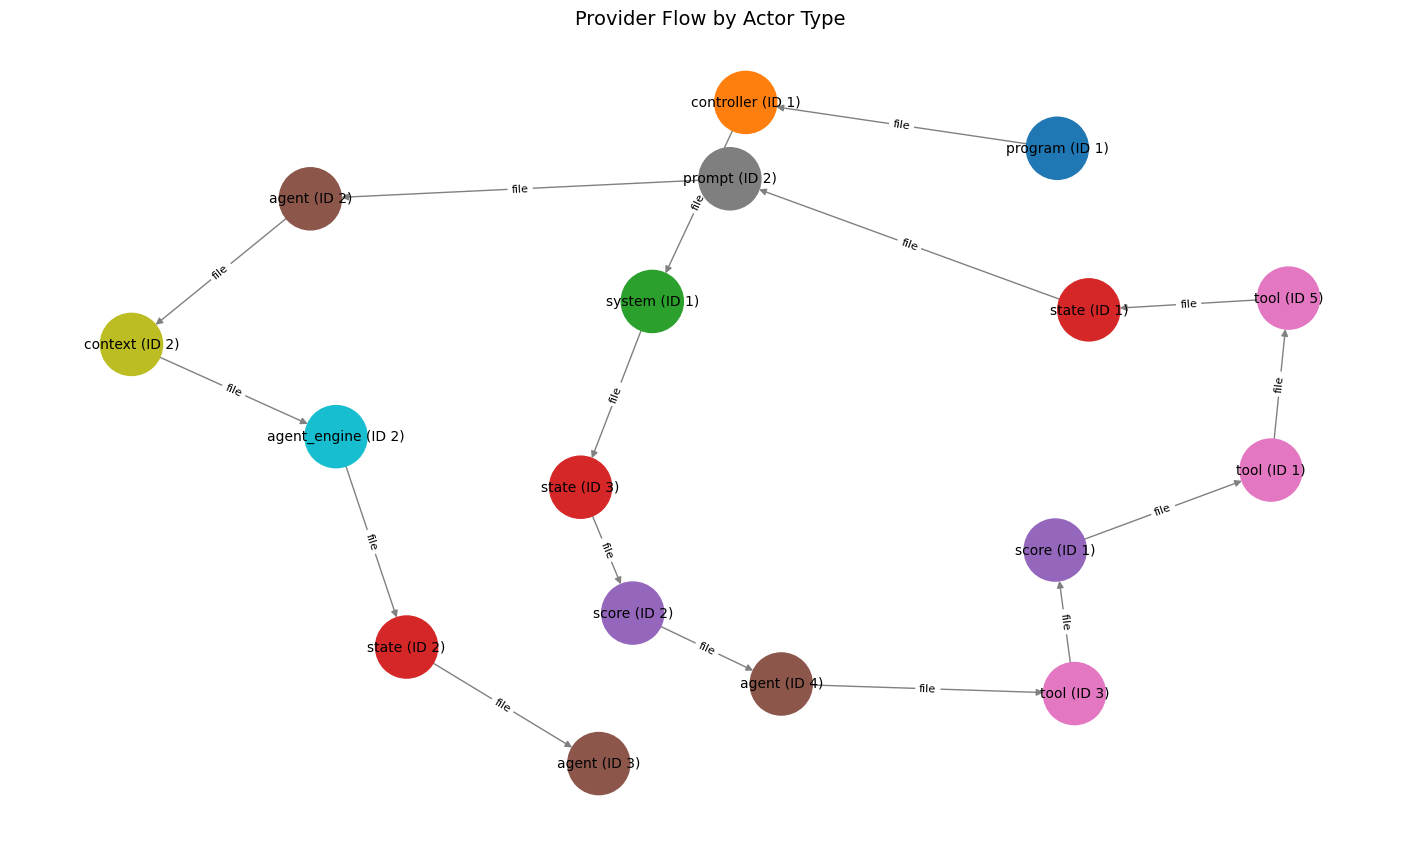

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

# Sort and dedupe by provider (only first appearance matters here)
df_files = df[df["file_name"].notna()].sort_values("timestamp").copy()
df_files = df_files[["timestamp", "provider_type", "provider_id", "file_name"]].drop_duplicates()
df_files["node"] = df_files.apply(lambda row: f"{row['provider_type']} (ID {row['provider_id']})", axis=1)

# One row per provider node
df_nodes = df_files.drop_duplicates(subset=["node"]).reset_index(drop=True)

# Build node color mapping
provider_types = df_nodes["provider_type"].unique()
color_map = dict(zip(provider_types, plt.get_cmap("tab10").colors[:len(provider_types)]))
node_colors = df_nodes["provider_type"].map(color_map)

# Build edges between nodes (based on execution order)
edges = []
for i in range(1, len(df_nodes)):
    prev = df_nodes.iloc[i - 1]
    curr = df_nodes.iloc[i]
    edges.append((prev["node"], curr["node"], curr["file_name"]))

# Create graph
G = nx.DiGraph()
for src, tgt, label in edges:
    G.add_edge(src, tgt, label="file")

# Draw with color
plt.figure(figsize=(14, 8))
pos = nx.spring_layout(G, k=0.6, seed=32)  # 🔒 fixed layout

nx.draw(
    G, pos,
    with_labels=True,
    labels={node: node for node in G.nodes},
    node_color=node_colors,
    node_size=2000,
    edge_color='gray',
    arrows=True,
    font_size=10
)

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=nx.get_edge_attributes(G, 'label'),
    font_size=8
)

plt.title("Provider Flow by Actor Type", fontsize=14)  # ⛔ no unsupported emoji
plt.show()

### 📊 Frequency of Provider Types in Execution

This bar chart displays the **number of times each `provider_type` appears** in the execution log.

#### 🧠 What this code does:
- Groups the log (`df`) by `provider_type` and counts how many entries exist for each type (e.g., `agent`, `tool`, `score`, `state`, etc.).
- Uses Plotly Express to render a **bar chart** with the provider types on the x-axis and their respective frequencies on the y-axis.
- Adds labels and color-coding to make the chart more interpretable and visually distinct.

#### 🔍 What you're observing:
- **Higher bars** indicate providers that are invoked more frequently (e.g., tools may appear often during scoring).
- Can help reveal which components dominate system activity.
- Serves as a quick summary of system behavior — useful for tuning, bottleneck detection, or debugging repeated execution patterns.

This is a foundational metric for system observability, especially when comparing runs or systems with different configurations.


In [8]:
import plotly.express as px

# Count how many times each provider type appears
provider_freq = df["provider_type"].value_counts().reset_index()
provider_freq.columns = ["provider_type", "count"]

# Plot as bar chart
fig = px.bar(
    provider_freq,
    x="provider_type",
    y="count",
    text="count",
    title="📊 Frequency of Provider Types in Execution",
    labels={"provider_type": "Provider Type", "count": "Occurrences"},
    color="provider_type",
    color_discrete_sequence=px.colors.qualitative.Set3
)
fig.update_traces(textposition="outside")
fig.update_layout(xaxis_title="Provider Type", yaxis_title="Count")
fig.show()


### ⏱️ Total Latency by Provider Type

This bar chart summarizes the **cumulative execution time** consumed by each `provider_type` across the entire session.

#### 🧠 What this code does:
- Aggregates the `latency_ms` field for each `provider_type` using `.groupby()` and `.sum()`.
- Sorts the result so the most time-consuming providers appear first.
- Uses Plotly Express to render a labeled **bar chart** with:
  - Provider types on the x-axis
  - Total latency (in milliseconds) on the y-axis
- Applies a pastel color palette for clarity and visual grouping.

#### 🔍 What you're observing:
- This reveals which components are the **most performance-intensive** — e.g., `agent_engine`, `tool`, or `system`.
- It complements frequency charts by showing not just how often a provider is used, but how **expensive** it is.
- Useful for identifying where to focus **optimization**, **caching**, or **parallelization** efforts.

This chart is essential for profiling execution cost at a subsystem level and for balancing responsiveness across an FSM-managed system.


In [9]:
import plotly.express as px

# Sum latency by provider type
latency_by_type = (
    df.groupby("provider_type")["latency_ms"]
    .sum()
    .reset_index()
    .sort_values("latency_ms", ascending=False)
)

# Plot as bar chart
fig = px.bar(
    latency_by_type,
    x="provider_type",
    y="latency_ms",
    text="latency_ms",
    title="⏱️ Total Latency by Provider Type",
    labels={"provider_type": "Provider Type", "latency_ms": "Total Latency (ms)"},
    color="provider_type",
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_traces(textposition="outside")
fig.update_layout(xaxis_title="Provider Type", yaxis_title="Total Latency (ms)")
fig.show()


### ⏱️ Average Latency per Call by Provider Type

This bar chart displays the **average execution time per invocation** for each `provider_type`, providing a normalized view of performance cost.

#### 🧠 What this code does:
- Groups the log (`df`) by `provider_type`.
- Calculates:
  - **Total latency** (`sum`)
  - **Call count** (`count`)
  - **Average latency per call** (normalized by dividing total by count)
- Rounds the average values to **integers** for cleaner chart labels.
- Renders a **bar chart** with color-coded provider types using a consistent palette.

#### 🔍 What you're observing:
- This view accounts for how frequently a provider is called, exposing **per-call cost**.
- Helpful for spotting **low-frequency but expensive providers** (e.g., `agent_engine`) vs. **high-frequency lightweight tools**.
- Guides decisions around **caching**, **parallelization**, or **refactoring** based on execution efficiency.

Use this alongside total latency charts to balance **frequency** and **impact** across the system.


In [10]:
import plotly.express as px

# Compute total latency and count
latency_stats = (
    df.groupby("provider_type")["latency_ms"]
    .agg(total_latency="sum", call_count="count")
    .reset_index()
)

# Calculate average latency per call
latency_stats["avg_latency_per_call"] = latency_stats["total_latency"] / latency_stats["call_count"]

# Convert label values to integers for display
latency_stats["avg_latency_label"] = latency_stats["avg_latency_per_call"].round().astype(int)

# Sort for visual clarity
latency_stats = latency_stats.sort_values("avg_latency_per_call", ascending=False)

# Plot
fig = px.bar(
    latency_stats,
    x="provider_type",
    y="avg_latency_per_call",
    text="avg_latency_label",
    title="⏱️ Average Latency per Call by Provider Type",
    labels={"provider_type": "Provider Type", "avg_latency_per_call": "Avg Latency (ms)"},
    color="provider_type",
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(textposition="outside")
fig.update_layout(xaxis_title="Provider Type", yaxis_title="Average Latency (ms)")
fig.show()
